In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
import dask
import xarray as xr
from pathlib import Path
import glob
from torch.distributions import Normal
import torch
from torch.utils.data import DataLoader
from torch.optim import lr_scheduler
from torch.distributions.multivariate_normal import MultivariateNormal
from losses import WeightedMSEKLD, WeightedMSE, BCElossKLD
from preprocessing import align_data_and_targets, create_mask, pole_centric, reverse_pole_centric, segment, reverse_segment, pad_xarray, smoother, align_data_and_targets
from preprocessing import AnomaliesScaler_v1_seasonal, AnomaliesScaler_v2_seasonal, Standardizer, Normalizer, PreprocessingPipeline, calculate_climatology, bias_adj, zeros_mask_gen
from torch_datasets import XArrayDataset
import torch.nn as nn
# from subregions import subregions
from data_locations import LOC_FORECASTS_SI, LOC_OBSERVATIONS_SI
import glob
import gc
import umap
# specify data directories
data_dir_forecast = LOC_FORECASTS_SI


/space/hall5/sitestore/eccc/crd/ccrn/users/rpg002/miniconda3/envs/rsaenv_neurips/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def power(ds,num_bins = 100,
          anomalies=False):
 
    R_earth_km = 6371
    if anomalies:
        ds_anoms = ds - ds.mean(['lat','lon'])
    else:
        ds_anoms = ds.copy()
 
    # grid = pysh.SHGrid.from_array(ds_anoms)
    # coeffs = grid.expand()
    # spectrum = coeffs.spectrum(lmax=coeffs.lmax)
 
    # l_values = np.arange(1, len(spectrum))  # Degrees l start from 1 (skip l=0)
    # wavelengths_km = 2 * np.pi * R_earth_km / l_values
    fft2 = np.fft.fft2(ds_anoms)
    psd2d = np.abs(fft2)**2         # 2D power spectrum (not normalized)
    psd2d = np.fft.fftshift(psd2d) 
    n_lat, n_lon = ds_anoms.shape
    dlat = 1      # deg per pixel (change if yours is different)
    dlon = 1 
    freq_lat = np.fft.fftshift(np.fft.fftfreq(n_lat, dlat))
    freq_lon = np.fft.fftshift(np.fft.fftfreq(n_lon, dlon))

    f_lon_grid, f_lat_grid = np.meshgrid(freq_lon, freq_lat)
    freq_r = np.sqrt(f_lat_grid**2 + f_lon_grid**2)  
    freq_r_flat = freq_r.ravel()
    psd_flat = psd2d.ravel()

    if num_bins is None:
        num_bins = min(n_lat, n_lon)//2   # or, pick your preferred number of bins
    bins = np.linspace(0, np.max(freq_r), num_bins+1)
    bin_centers = 0.5*(bins[:-1] + bins[1:])

    # Calculate mean power in each radial bin
    radial_mean_power = np.zeros(num_bins)
    for i in range(num_bins):
        in_bin = (freq_r_flat >= bins[i]) & (freq_r_flat < bins[i+1])
        if np.any(in_bin):
            radial_mean_power[i] = np.mean(psd_flat[in_bin])
        else:
            radial_mean_power[i] = 0.0

    return radial_mean_power, bin_centers



def reliability(pred_ens, obs: XArrayDataset, lead_time = 1, normalized = True, use_ref_edge = True, min_edge = 0.05, max_edge = 0.9):

    
    pred_ens = xr.DataArray(pred_ens, dims = ('ensembles', 'time', 'lat', 'lon'))

    num_bin = len(pred_ens.ensembles) + 1

    obs_edge = obs.where((obs >= min_edge) & (obs <=max_edge) )

    if use_ref_edge:
        nn_edge = pred_ens.where(~np.isnan(obs_edge) )
    else:
        nn_edge = pred_ens.where((pred_ens >= min_edge) & (pred_ens <=max_edge) )

    sorted_nn = xr.full_like(nn_edge, fill_value = np.nan)
    sorted_nn[:] = np.sort(nn_edge.values, axis=nn_edge.dims.index('ensembles'))

    da = sorted_nn - obs_edge
    mask = da.sum('ensembles').where(da.sum('ensembles') != 0) 
    mask = mask.where(np.isnan(mask),1)

    da = da * mask
    mask2 = da > 0
    da = ( mask2.argmax('ensembles') )* mask

    has_positive = mask2.any(dim='ensembles')
    da = da.where(has_positive, num_bin) * mask

    if normalized:
        da = da/(num_bin)

    return da


   
def reverse_pole_centric_array(ds,  pole = 'North'):
        
        d1 = ds[...,:int(ds.shape[-2]/2),:]
        d2 = np.flip(ds[...,int(ds.shape[-2]/2):,:], -1) 

        if pole == 'North':
            return  np.concatenate([d1, np.flip(d2, axis = -2)], axis = -1)
        else:
            return  np.concatenate([d2, np.flip(d1, axis = -2)], axis = -1)


  



In [3]:
def extract_params(model_dir):
    params = {}
    path = glob.glob(model_dir + '/*.txt')[0]
    file = open(path)
    content=file.readlines()
    for line in content:
        if '\t' in line:
            key = line.split('\t')[0]
            try:
                value = line.split('\t')[1].split('\n')[0]
            except:
                value = line.split('\t')[1]
            try:    
                params[key] = eval(value)
            except:
                if key == 'ensemble_list':
                    ls = []
                    for item in value.split('[')[1].split(']')[0].split(' '):
                        try:
                            ls.append(eval(item))
                        except:
                            pass
                    params[key] = ls
                else:
                    params[key] = value
    return params

In [4]:
class trained_net():
    def __init__( self, out_dir,   model_year, ds_raw_ensemble_mean, obs_raw, land_mask, model_mask, NPSProj, subset_dimensions, device = 'cpu' ):
        params = self.extract_params(out_dir)
        print(f'loaded configuration: \n')
        for key, values in params.items():
            print(f'{key} : {values} \n')

        version = eval(out_dir.split('/')[-1].split('_')[3][1:]) if 'VAL' not in out_dir else eval(out_dir.split('/')[-1].split('_')[4][1:])
        params["version"] = version
        print( f'Version: {version}')

        
        if 'Linear' in out_dir:
                params['VAE_MLP_encoder'] = True

        try:
            scale_factor_channels = params['scale_factor_channels']
        except:
            scale_factor_channels = None

        params["obs_clim"] = False
        params['forecast_range_months'] = eval(out_dir.split('_F')[1].split('_')[0])
        if 'LT' in out_dir:
            lead_time = eval(out_dir.split('_LT')[1].split('_')[0])
        else:
            lead_time = None
        if 'combined' in out_dir:
            params['combined_prediction'] = True
        else:
            params['combined_prediction'] = False

        params['VAE_latent_size'] = eval(out_dir.split('_LS')[1].split('_')[0])
        if params['version'] == 2:

            params['forecast_preprocessing_steps'] = [
                ('anomalies', AnomaliesScaler_v1_seasonal())]
            params['observations_preprocessing_steps'] = []
            
        else:
            params['forecast_preprocessing_steps'] = []
            params['observations_preprocessing_steps'] = []


        if params['version'] == 'IceExtent':
            params['reg_scale'] = None
            params['combined_prediction'] = False

        if '-DecoderVar' in out_dir:
            params['output_sampling'] = 'learn_decoder_variance'
            learn_decoder_variance =  True
            print('Decoder sampling from learned variance matrix available!')
            

        elif '-DecoderRes' in out_dir:
            params['output_sampling'] = None
            params['learn_decoder_residual'] = True
            print('Decoder residual network available!')
            
        else:
            params['learn_decoder_residual'] = False
            learn_decoder_variance = False

        if 'learn_decoder_sampler' not in params.keys():
            params['learn_decoder_sampler'] = {'status' : False, 'noise_std' : None}
        else:
            params['output_sampling'] = None
        
        if 'noise_injection_level' not in params['learn_decoder_sampler'].keys():
            params['learn_decoder_sampler']['noise_injection_level'] = 'medium'

        try:
            Final_kernel_2 = params['Final_kernel_2']
        except:
            Final_kernel_2 = False     
        ############################################## load data ##################################
        time_features = params["time_features"]

        model = (params['model'])
        forecast_preprocessing_steps = params["forecast_preprocessing_steps"]
        observations_preprocessing_steps = params["observations_preprocessing_steps"]
        if 'skip_VAE_added_dim' not in params.keys():
            params['skip_VAE_added_dim'] = False
        try:
            ensemble_mode = params['ensemble_mode']
        except:
            params['ensemble_mode'] = 'Mean'

        try:
            obs_clim = params["obs_clim"]
        except: 
            pass
        try:
            LocallyConnected = params['LocallyConnected']
        except:
            LocallyConnected = False

        if any([params['active_grid'],'active_mask' in params["time_features"], 'full_ice_mask' in params["time_features"]]):
            if 'ensembles'  in obs_raw.dims:
                zeros_mask_full = xr.concat([zeros_mask_gen(obs_raw.isel(ensembles = 0).isel(lead_time = 0).drop('lead_time').where(obs_raw.time<model_year *100, drop = True ), 3) ], dim = 'test_year').assign_coords(test_year = model_year)
            else:
                zeros_mask_full = xr.concat([zeros_mask_gen(obs_raw.isel(lead_time = 0).drop('lead_time').where(obs_raw.time<model_year *100, drop = True ), 3) ], dim = 'test_year').assign_coords(test_year = model_year)           
                            
            for item in ['active_mask', 'full_ice_mask']:
                zeros_mask_full = zeros_mask_full.drop(item) if item not in params["time_features"] else zeros_mask_full
            zeros_mask_full = zeros_mask_full.drop('active_grid') if not params['active_grid'] else zeros_mask_full

            zeros_mask_full = zeros_mask_full.expand_dims('channels', axis=-3)
            if 'ensembles' in ds_raw_ensemble_mean.dims:
                    zeros_mask_full = zeros_mask_full.expand_dims('ensembles', axis=2)

        if params['version'] == 'IceExtent':
            obs_raw = obs_raw.where(obs_raw>=0.15,0)
            obs_raw = obs_raw.where(obs_raw ==0 , 1)
            learn_decoder_variance = False
            params['loss_function'] = 'BCELoss'
        if params['combined_prediction']:
            obs_raw_ = obs_raw.where(obs_raw>=0.15,0)
            obs_raw_ = obs_raw_.where(obs_raw_ ==0 , 1)
            obs_raw = xr.concat([obs_raw, obs_raw_], dim = 'channels')
            params['loss_function'] = 'combined'
            params['learn_decoder_residual'] = False
            del obs_raw_


        if NPSProj is False:
            
                ds_raw_ensemble_mean = pole_centric(ds_raw_ensemble_mean, subset_dimensions)
                obs_raw =  pole_centric(obs_raw, subset_dimensions)
                land_mask = pole_centric(land_mask, subset_dimensions)
                model_mask = pole_centric(model_mask, subset_dimensions)
                if any([params['active_grid'],'active_mask' in params["time_features"], 'full_ice_mask' in params["time_features"]]):
                    zeros_mask_full = pole_centric(zeros_mask_full, subset_dimensions)

        self.train_years = ds_raw_ensemble_mean.time[ds_raw_ensemble_mean.time <= (model_year)*100].to_numpy() 

        if lead_time is not None:
            full_shape = xr.full_like(ds_raw_ensemble_mean, np.nan).isel(lat = slice(1,2), lon = slice(1,2))
            ds_raw_ensemble_mean = ds_raw_ensemble_mean.sel(lead_time = slice(lead_time,lead_time))
            obs_raw = obs_raw.sel(lead_time = slice(lead_time,lead_time))



        if any([params['active_grid'],'active_mask' in params["time_features"], 'full_ice_mask' in params["time_features"]]):
            self.zeros_mask = zeros_mask_full.sel(test_year = model_year).drop('test_year')
        else:
            self.zeros_mask = None

        n_train = len(self.train_years)
        train_mask = create_mask(ds_raw_ensemble_mean[:n_train,...]) if lead_time is None else create_mask(full_shape[:n_train,...])[:, lead_time - 1][..., None] ############

        ds_baseline = ds_raw_ensemble_mean[:n_train,...]
        obs_baseline = obs_raw[:n_train,...].isel(channels = slice(0,1))


        if 'ensembles' in ds_raw_ensemble_mean.dims: ## PG: Broadcast the mask to the correct shape if you have an ensembles dim.
            preprocessing_mask_fct = np.broadcast_to(train_mask[...,None,None,None,None], ds_baseline.shape)

        else:
            preprocessing_mask_fct = np.broadcast_to(train_mask[...,None,None,None], ds_baseline.shape)

        if 'ensembles' in obs_raw.dims: 
            preprocessing_mask_obs = np.broadcast_to(train_mask[:n_train ,...,None, None,None,None], obs_baseline.shape)
        else:
            preprocessing_mask_obs = np.broadcast_to(train_mask[:n_train ,..., None,None,None], obs_baseline.shape)

        if params['version']  in [3,1.1]:
            sigmoid_activation = False
        else:
            sigmoid_activation = True

        # Data preprocessing

        ds_pipeline = PreprocessingPipeline(forecast_preprocessing_steps).fit(ds_baseline, mask=preprocessing_mask_fct)
        ds = ds_pipeline.transform(ds_raw_ensemble_mean)

        obs_pipeline = PreprocessingPipeline(observations_preprocessing_steps).fit(obs_baseline, mask=preprocessing_mask_obs)
        obs = obs_pipeline.transform(obs_raw.isel(channels = slice(0,1)))

        if params['combined_prediction']:
                obs = xr.concat([obs, obs_raw.isel(channels = slice(1,2))], dim  = 'channels')  

        del ds_baseline, obs_baseline, preprocessing_mask_obs, preprocessing_mask_fct
        gc.collect()


        if 'land_mask' in time_features:
                ds = xr.concat([ds, land_mask.expand_dims('channels', axis = 0)], dim = 'channels')


        if time_features is None:
            self.add_feature_dim = 0
        else:
            self.add_feature_dim = len(time_features)
        if 'land_mask' in time_features:
            self.add_feature_dim -= 1
        if 'ensemble_error' in time_features:
            add_feature_dim -= 1

        self.n_channels_x = len(ds.channels)

        if 'path_to_deterministic' not in params.keys():
            params['path_to_deterministic'] = None

        if params['path_to_deterministic'] is not None:
            from preprocessing import extract_params
            
            params_saved = extract_params(params['path_to_deterministic'])
            NPSProj_saved = False if '1x1' in params['path_to_deterministic'] else True          
            params_saved['combined_prediction'] = True if 'combined' in params['path_to_deterministic'] else False
            lead_time_saved = eval(params['path_to_deterministic'].split('_LT')[1].split('_')[0]) if 'LT' in params['path_to_deterministic'] else None
            n_val_year_saved = int(params['path_to_deterministic'].split('_VAL')[1][:1]) if '_VAL' in params['path_to_deterministic'] else 0
            try:
                LocallyConnected_saved = params_saved['LocallyConnected']
            except:
                LocallyConnected_saved = False
            assert NPSProj_saved == NPSProj, 'The saved deterministic model cannot have a trained for a different projection than your cVAE!'
            version_saved = eval(params['path_to_deterministic'].split('/')[-1].split('_')[3][1:]) if 'VAL' not in params['path_to_deterministic'] else eval(params['path_to_deterministic'].split('/')[-1].split('_')[4][1:])
            if params['version'] == 'IceExtent':
                assert version_saved in  ['IceExtent', 1]
            else:
                assert version_saved == params['version'], 'The saved deterministic model cannot have a different version than your cVAE!'
            assert lead_time_saved == lead_time, 'The saved deterministic model cannot have a trained for a different lead_time than your cVAE!'
            assert params['time_features'] == params_saved['time_features'], 'The saved deterministic model must have the same input as your cVAE for the model data and added features!'
            assert params_saved['combined_prediction'] == params['combined_prediction'], 'The saved deterministic model must have the same output type as your cVAE'
            assert LocallyConnected == LocallyConnected_saved, 'The saved deterministic model must have the same output layer as your cVAE'
            try:
                Final_kernel_2_saved = params_saved['Final_kernel_2']
            except:
                Final_kernel_2_saved = False  
            import_last_conv = False if Final_kernel_2 != Final_kernel_2_saved else True
            from models.unetconvnext import UNet2,UNet2_NPS
            model = eval(params_saved['model'])
            unet = model(n_channels_x= self.n_channels_x+ self.add_feature_dim , bilinear = params_saved['bilinear'], sigmoid = sigmoid_activation, skip_conv = params_saved['skip_conv'], combined_prediction = params_saved['combined_prediction'], LocallyConnected = LocallyConnected_saved)
            try:
                saved_model_dir = glob.glob(params['path_to_deterministic']+ f'/Checkpoints/*-{model_year}*.pth')
                saved_model_dir.sort()
                unet.load_state_dict(torch.load(saved_model_dir[0], map_location=torch.device('cpu'))) 
            except:
                unet.load_state_dict(torch.load(glob.glob(params['path_to_deterministic']+ f'/Checkpoints/*final*-{model_year - 1}*.pth')[0], map_location=torch.device('cpu'))) 

        else:
            unet = None

        # if params['path_to_encoder_prior'] is not None:
        #         from preprocessing import extract_params
                
        #         params_saved = extract_params(params['path_to_encoder_prior'])
        #         NPSProj_saved = False if '1x1' in params['path_to_encoder_prior'] else True          
        #         params_saved['combined_prediction'] = True if 'combined' in params['path_to_encoder_prior'] else False
        #         lead_time_saved = eval(params['path_to_encoder_prior'].split('_LT')[1].split('_')[0]) if 'LT' in params['path_to_encoder_prior'] else None
        #         n_val_year_saved = int(params['path_to_encoder_prior'].split('_VAL')[1][:1]) if '_VAL' in params['path_to_encoder_prior'] else 0
        #         try:
        #             LocallyConnected_saved = params_saved['LocallyConnected']
        #         except:
        #             LocallyConnected_saved = False
        #         try:
        #             Final_kernel_2_saved = params_saved['Final_kernel_2']
        #         except:
        #             Final_kernel_2_saved = False                    

        #         assert NPSProj_saved == NPSProj, 'The saved encoder/prior model cannot have been trained for a different projection than your cVAE!'
        #         version_saved = eval(params['path_to_encoder_prior'].split('/')[-1].split('_')[3][1:]) if 'VAL' not in params['path_to_encoder_prior'] else eval(params['path_to_encoder_prior'].split('/')[-1].split('_')[4][1:])
        #         if params['version'] == 'IceExtent':
        #             assert version_saved in  ['IceExtent', 1]
        #         else:
        #             assert version_saved == params['version'], 'The saved encoder/prior model cannot have a different version than your cVAE!'
        #         assert lead_time_saved == lead_time, 'The saved encoder/prior model cannot have been trained for a different lead_time than your cVAE!'
        #         assert params['time_features'] == params_saved['time_features'], 'The saved encoder/prior model must have the same input as your cVAE for the model data and added features!'
        #         assert params_saved['combined_prediction'] == params['combined_prediction'], 'The saved encoder/prior model must have the same output type as your cVAE'
        #         assert LocallyConnected == LocallyConnected_saved, 'The saved encoder/prior model must have the same type output layer as your cVAE'
        #         import_last_conv = False if Final_kernel_2 != Final_kernel_2_saved else True
        #         assert all([params['VAE_latent_size'] == params_saved['VAE_latent_size'], 
        #                     params['VAE_MLP_encoder'] == params_saved['VAE_MLP_encoder']]), 'The saved encoder/prior model must have the same latent space as your cVAE'
        #         assert all([params_saved['scale_factor_channels'] == params['scale_factor_channels'], params_saved['skip_VAE_added_dim'] == params['skip_VAE_added_dim'],
        #                     params['path_to_deterministic'] == params_saved['path_to_deterministic']]), 'The saved encoder/prior model must have the same architecture as your cVAE'
        #         if 'noise_injection_level' not in params_saved['learn_decoder_sampler']:
        #             params_saved['learn_decoder_sampler']['noise_injection_level'] = 'medium'

        #         model = eval(params_saved['model'])
                
        #         cvae_base = cVAE(VAE_latent_size = params_saved['VAE_latent_size'], n_channels_x= self.n_channels_x+ self.add_feature_dim , sigmoid = sigmoid_activation, NPS_proj = NPSProj, combined_prediction = params_saved['combined_prediction'], VAE_MLP_encoder = params_saved['VAE_MLP_encoder'],
        #                 scale_factor_channels = params_saved['scale_factor_channels'], skip_VAE_added_dim = params_saved['skip_VAE_added_dim'], saved_deterministic_model = unet, freeze_deterministic = True,
        #                     learn_decoder_variance = params_saved['learn_decoder_variance']['status'], noise_injection_std = params_saved['learn_decoder_sampler']['noise_std'], noise_injection_level =  params_saved['learn_decoder_sampler']['noise_injection_level'], LocallyConnected= LocallyConnected_saved, Final_kernel_2 = Final_kernel_2_saved, device=device) 
        #         try:
        #             saved_model_dir = glob.glob(params['path_to_encoder_prior']+ f'/Checkpoints/*-{model_year}*.pth')
        #             saved_model_dir.sort()
        #             cvae_base.load_state_dict(torch.load(saved_model_dir[0], map_location=torch.device('cpu')))
        #         except:
        #             cvae_base.load_state_dict(glob.glob(params['path_to_encoder_prior']+ f'/Checkpoints/*final*-{model_year - 1}*.pth')[0], map_location=torch.device('cpu'))
        # else:
        #     cvae_base = None            

        if 'DetRess' in out_dir:
            self.net = cVAE(VAE_latent_size = params['VAE_latent_size'], n_channels_x= self.n_channels_x+ self.add_feature_dim , sigmoid = sigmoid_activation, NPS_proj = NPSProj, VAE_MLP_encoder = params['VAE_MLP_encoder'],
                            scale_factor_channels = params['scale_factor_channels'], skip_VAE_added_dim = params['skip_VAE_added_dim'], saved_deterministic_model = unet, 
                                learn_decoder_variance = params['learn_decoder_variance']['status'], noise_injection_std = params['learn_decoder_sampler']['noise_std'],  noise_injection_level = params['learn_decoder_sampler']['noise_injection_level'], LocallyConnected= LocallyConnected, device=device)   #temporarily not input to check whether sending the net to device does automatically take care of this

        else:
            self.net = cVAE(VAE_latent_size = params['VAE_latent_size'], n_channels_x= self.n_channels_x+ self.add_feature_dim , sigmoid = sigmoid_activation, NPS_proj = NPSProj, device=device, combined_prediction = params['combined_prediction'],scale_factor_channels = scale_factor_channels,
                    VAE_MLP_encoder = params['VAE_MLP_encoder'], skip_VAE_added_dim = params['skip_VAE_added_dim'], saved_deterministic_model = unet, learn_decoder_variance = learn_decoder_variance, noise_injection_std = params['learn_decoder_sampler']['noise_std'],  noise_injection_level = params['learn_decoder_sampler']['noise_injection_level'], LocallyConnected=LocallyConnected )


        print('Loading model ....')

        model_links = glob.glob(out_dir + f'/Checkpoints/*-{model_year}*.pth') ### Changed 0717 when best model is saved in Checkpoint ####
        if len(model_links) == 0:
            model_links = glob.glob(out_dir + f'/Checkpoints/*final*-{model_year - 1}*.pth')   ### Changed 0717 when best model is saved in Checkpoint ####
            # if len(model_links) == 0:
            #     model_links = glob.glob(model_dir + f'/Checkpoints/*-{model_year_}*.pth') ### Changed 0717 when best model is saved in Checkpoint ####
        model_links.sort()
        if 'parallel' in out_dir:
            net_state_dict = torch.load(model_links[0], map_location=torch.device('cpu'))
            new_state_dict = {}
            for key, value in net_state_dict.items():
                if key.startswith('module.'):
                    new_state_dict[key[7:]] = value  # Remove "module." (7 chars)
                else:
                    new_state_dict[key] = value
            self.net.load_state_dict(new_state_dict)
        else:
            self.net.load_state_dict(torch.load(model_links[0], map_location=torch.device('cpu'))) 

        try:
            del unet, params_saved
            gc.collect()
        except:
            pass 


        if lead_time is not None:
            mask =  create_mask(full_shape)[:n_train]  #create_mask(ds)[:n_train]
        else:
            mask = train_mask

        self.out_dir = out_dir
        self.net.to(device)
        self.net.eval()

        self.ds = ds
        self.obs = obs
        self.time_features = time_features
        self.params = params
        self.model_year = model_year
        self.mask_dataset = mask
        self.lead_time = lead_time
        self.device = device
        self.n_train = n_train
        self.land_mask = land_mask
        self.model_mask = model_mask
        del ds, obs 
        gc.collect()

    def create_train_set(self, masked = True):
                
        ds_train = self.ds[:self.n_train,...]
        obs_train = self.obs[:self.n_train,...]
        if masked:
            mask  = self.mask_dataset
        else:
            mask = None
        return  XArrayDataset(ds_train, obs_train, mask=mask, zeros_mask = self.zeros_mask, in_memory=False, lead_time=self.lead_time, time_features=self.time_features, aligned = True,  model = 'UNet2') 
    
    def create_test_set(self):
        
        ds_test = self.ds[self.n_train: ,...]
        obs_test = self.obs[self.n_train: ,...]
        if 'ensembles' in obs_test.dims:
            obs_test = obs_test.mean('ensembles')
        return  XArrayDataset(ds_test, obs_test, mask=None, zeros_mask = self.zeros_mask, in_memory=False, lead_time=self.lead_time, time_features=self.time_features, aligned = True,  model = 'UNet2') 
                    
    

    def predict(self, x, y,  latent_sample_size, noise_injection_sample_size, latent_dist, n_stds = 1, z_samples = None, return_preds = True ):
        if not return_preds:
            assert z_samples is None, 'With return_preds = False there is no calculations to do if z_samples are specified'

        model_mask_ = torch.from_numpy(self.model_mask.to_numpy()).unsqueeze(0)
        model_mask_ = model_mask_.expand(self.n_channels_x + self.add_feature_dim,*self.model_mask.shape)
        obs_mask = torch.from_numpy(self.land_mask.to_numpy()).unsqueeze(0)
        model_mask_ = model_mask_.to(y)
        obs_mask = obs_mask.to(y)
        
        # if latent_dist == 'recognition':
        #     if any([ mu is not None, log_var is not None]):
        #         assert all([ mu is not None, log_var is not None])
        # elif latent_dist == 'prior':
        #     if any([ cond_mu is not None, cond_log_var is not None]):
        #         assert all([  cond_mu is not None, cond_log_var is not None])

        with torch.no_grad():
            learn_decoder_variance_training_step = self.params['learn_decoder_variance']['status']
            decoder_inject_noise = self.params['learn_decoder_sampler']['status']
            if not decoder_inject_noise:
                noise_injection_sample_size = 1


            obs_mask = obs_mask.expand_as(y[0])

            # generated_output, _, _, _ , _, _ = net(y, obs_mask, x, model_mask_, sample_size = 1 ) 
            if z_samples is None:
                z_samples_loaded = False
                if self.params['learn_decoder_variance']['status']:
                    _, _, _, mu, log_var , cond_mu, cond_log_var = self.net(y, obs_mask, x, model_mask_, sample_size = self.params['learn_decoder_sampler']["decoder_sample_size"], inject_noise = decoder_inject_noise )
                else:
                    _, _, mu, log_var , cond_mu, cond_log_var = self.net(y, obs_mask, x, model_mask_, sample_size = self.params['learn_decoder_sampler']["decoder_sample_size"], inject_noise = decoder_inject_noise )
            else:
                z_samples_loaded = True
            
            if 'DetRess' not in self.out_dir:
                basic_unet = self.net.unet(x, model_mask_) if not self.net.loaded_unet else self.net.unet(x, model_mask_[0,...])
            else:
                deterministic_output = self.unet(x, model_mask_[0,...])  
            
            decoder_sampler_list = []

            if z_samples is None:
                if latent_dist == 'prior':
                    var = torch.exp(cond_log_var) + 1e-4
                    std = torch.sqrt(var)
                    z_samples =  Normal(cond_mu, std * n_stds).rsample(sample_shape=(latent_sample_size,)).to(self.device)
                elif latent_dist == 'recognition':
                    var = torch.exp(log_var) + 1e-4
                    std = torch.sqrt(var)   
                    z_samples =  Normal(mu, std * n_stds).rsample(sample_shape=(latent_sample_size,)).to(self.device)
            else:
                assert z_samples.shape[1] == y.shape[0]

            if not return_preds:
                return  z_samples, mu, log_var, cond_mu, cond_log_var
            
            else:

                if self.lead_time is None:
                    z = torch.flatten(z_samples, start_dim = 0, end_dim = 1)
                else:
                    z = z_samples.copy()

                for sample in range(noise_injection_sample_size):  
                    if self.params['learn_decoder_sampler']['status']:
                        out = self.net.generation(z, inject_noise = True)
                    else:
                        out = self.net.generation(z)

                    if 'DetRess' in self.out_dir:
                        raise NotImplementedError()
                        # generated_output = torch.unflatten(self.net.last_conv(out), dim = 0, sizes = (latent_sample_size,y.shape[0]))
                        # generated_output = generated_output + deterministic_output 
                        # generated_output = torch.flatten(generated_output, start_dim = 0, end_dim = 1)  

                    else:
                        out = torch.unflatten(out, dim = 0, sizes = (latent_sample_size,y.shape[0]))
                        out = out + basic_unet.squeeze() 
                        out = torch.flatten(out, start_dim = 0, end_dim = 1)     

                        if hasattr(self.net, 'last_conv_trainable'):
                            if self.net.last_conv_trainable is not None:
                                generated_output = self.net.last_conv_trainable(out)
                            else:
                                generated_output = self.net.last_conv(out)
                        else:
                            generated_output = self.net.last_conv(out)

                    generated_output = torch.unflatten(generated_output , dim = 0, sizes = (latent_sample_size,y.shape[0]))
                    decoder_sampler_list.append(generated_output.unsqueeze(0).squeeze(-3).to(torch.device('cpu')).numpy())

                noise_injected_output = np.concatenate(decoder_sampler_list, axis = 0).clip(0,1) * self.land_mask.values


                if z_samples_loaded is False:
                    return  noise_injected_output, z_samples, mu, log_var, cond_mu, cond_log_var
                else:
                    return  noise_injected_output, z_samples
                

    def extract_params(self, model_dir):
        params = {}
        path = glob.glob(model_dir + '/*.txt')[0]
        file = open(path)
        content=file.readlines()
        for line in content:
            if '\t' in line:
                key = line.split('\t')[0]
                try:
                    value = line.split('\t')[1].split('\n')[0]
                except:
                    value = line.split('\t')[1]
                try:    
                    params[key] = eval(value)
                except:
                    if key == 'ensemble_list':
                        ls = []
                        for item in value.split('[')[1].split(']')[0].split(' '):
                            try:
                                ls.append(eval(item))
                            except:
                                pass
                        params[key] = ls
                    else:
                        params[key] = value
        return params



In [ ]:
out_dir_x  = f'/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/output/SI/Full/results/NOAA/cVAE/run_set_final_convnext_interp'
out_dir_x_crps  = f'/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/output/SI/Full/results/NOAA/cVAE/run_set_final_convnext_interp'

out_dir    = f'{out_dir_x}/N2_M12_VAL3_F12_v1.1_*_B0.01_CscaleNone_CVAE_50_LS1000_Linear_NPSproj_lr_scheduler_North_lr1e-05_batch10x1_e50_equalweights' 
out_dir_crps = f'{out_dir_x_crps}/N2_M12_VAL3_F12_v1.1_*_Banealing_CscaleNone_CVAE-DecoderSamplerV31-10-full_50_LS1000_Linear_NPSproj_cosine_lr_scheduler_North_lr1e-05_batch2x2_e50_equalweights_multi_ress_loss2_pretrainedUNETnotforzen' 
# if '_test' in out_dir_crps:
#     from models.cvae_1001_test import cVAE
if 'DecoderSamplerV01' in out_dir_crps:
    from models.cvae_1001 import cVAE
elif 'DecoderSamplerV17' in out_dir_crps:
    from models.cvae_0717 import cVAE
else:
    from models.cvae_1001 import cVAE

model_list = glob.glob(out_dir + '/Checkpoints/*.pth')
for item in model_list:
    print(item.split('/')[-1])

/home/rpg002/.local/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [7]:
model_year = 2016

obs_ref = 'NOAA'
NPSProj = False if '1x1' in out_dir else True
if NPSProj:
    crs = 'NPS'
else:
    crs = '1x1'

if 'CVAE2' in out_dir:
    ensemble_error = True
else:
    ensemble_error = False

# Fine_Tuned_from_Assim = False
target_ensemble_bootstrap = False
ensemble_list = None
ensemble_mode = 'Mean'

subset_dimensions = 'North'

lead_months = 12
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [8]:
LOC_OBSERVATIONS_SI

'/space/hall5/sitestore/eccc/crd/ccrn/users/rpg002/data/SI/observation'

In [ ]:
from preprocessing import load_model_data
# if Fine_Tuned_from_Assim:

if obs_ref == 'NASA':
    data_dir_obs = glob.glob(LOC_OBSERVATIONS_SI+ f'/NASA/*{crs}*.nc')[0] 
elif obs_ref == 'NOAA':
    assert crs == 'NPS'
    data_dir_obs = glob.glob(LOC_OBSERVATIONS_SI+ f'/NOAA/*{crs}*.nc')[0] 
else:
    data_dir_obs = glob.glob(LOC_OBSERVATIONS_SI+ '/uws*.nc')[0]

observation = xr.open_dataset(data_dir_obs)['SICN']
# else:

#     observation = xr.open_mfdataset(f'/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/SI/assimilation/*{crs}*.nc', 
#                             combine= 'nested', concat_dim='ensembles')['SICN'].transpose('time','ensembles',...).sortby('ensembles')

#     # if target_ensemble_ind is not None:
#     #     observation = observation.sel(ensembles = target_ensemble_ind).drop('ensembles')
#     #     print(f'Warining! Training only for ensemble member {target_ensemble_ind} from the assimilations')
#     if ensemble_list is not None:
#         observation = observation.sel(ensembles = ensemble_list)

print("Load forecasts")
fct = load_model_data(LOC_FORECASTS_SI, obs_ref, crs, ensemble_list, ensemble_mode)
if ensemble_mode.lower() == 'mean': 
    if ensemble_error:
        fct_std = load_model_data(LOC_FORECASTS_SI, obs_ref, crs, ensemble_list, ensemble_mode = 'std')
else:
    fct = fct.transpose('time','lead_time','ensembles',...)

# ls = [xr.open_dataset(glob.glob(LOC_FORECASTS_SI + f'/*_initial_month_{intial_month}_{obs_ref}*{crs}*.nc')[0]) for intial_month in range(1,13) ]
# fct = xr.concat(ls, dim = 'time').sortby('time')

# del ls
gc.collect()



Load forecasts


92

In [10]:
if ensemble_list is not None: ## PG: calculate the mean if ensemble mean is none
    hnd = load_model_data(LOC_FORECASTS_SI, obs_ref, crs, ensemble_list, ensemble_mode = 'LE') 
else:    ## Load specified members
    hnd = load_model_data(LOC_FORECASTS_SI, obs_ref, crs, ensemble_mode = 'LE') 


    
###### handle nan and inf over land ############
if not NPSProj:
    hnd = hnd.where(hnd<1000,np.nan) ### land is masked in model data with a large number
else:
    hnd = (hnd.rename({'x':'lon','y':'lat'}))
    if obs_ref == 'NASA':
        hnd = hnd[...,:,64:-64]

hnd = hnd.clip(0,1)
hnd = hnd.fillna(0)

In [11]:
if ensemble_error:
     ds_in_std = fct_std
###### handle nan and inf over land ############
if not NPSProj:
    ds_in = fct.where(fct<1000,np.nan) ### land is masked in model data with a large number
    # if not Fine_Tuned_from_Assim:
    #     observation = observation.where(observation<1000,np.nan)
else:
    # mask_projection = (xr.open_dataset(data_dir_obs)['mask'].rename({'x':'lon','y':'lat'}))[...,:,64:-64]
    observation = (observation.rename({'x':'lon','y':'lat'}))
    ds_in = (fct.rename({'x':'lon','y':'lat'}))
    if obs_ref == 'NASA':
        observation = observation[...,:,64:-64]
        ds_in = ds_in[...,:,64:-64]    
        if ensemble_error:
                ds_in_std = ds_in_std[...,:,64:-64] 

if 'ensembles' in observation.dims:
    land_mask = observation.isel(ensembles = 0).mean('time').where(np.isnan(observation.isel(ensembles = 0).mean('time')),1).fillna(0).drop('ensembles')
else:
    land_mask = observation.mean('time').where(np.isnan(observation.mean('time')),1).fillna(0)

model_mask = ds_in.mean('time')[0].where(np.isnan(ds_in.mean('time')[0]),1).fillna(0).drop('lead_time')
observation = observation.clip(0,1)
ds_in = ds_in.clip(0,1)
observation = observation.fillna(0)
ds_in = ds_in.fillna(0)
if ensemble_error:
    ds_in_std = ds_in_std.fillna(0)
############################################
if 'ensembles' in observation.dims:
    obs_in = observation.expand_dims('channels', axis=2)
else:
    obs_in = observation.expand_dims('channels', axis=1)

if 'ensembles' in ds_in.dims: ### PG: add channels dimention to the correct axis based on whether we have ensembles or not
    ds_in = ds_in.expand_dims('channels', axis=3)
else:
    ds_in = ds_in.expand_dims('channels', axis=2) 
    if ensemble_error:
            ds_in_std = ds_in_std.expand_dims('channels', axis=2)
            ds_in = xr.concat([ds_in, ds_in_std], dim = 'channels')




ds_raw, obs_raw = align_data_and_targets(ds_in, obs_in, lead_months, target_ensemble_bootstrap = target_ensemble_bootstrap)  # extract valid lead times and usable years ## used to be np.min(test_years)

del  obs_in
gc.collect()

if not ds_raw.time.equals(obs_raw.time): 
        ds_raw = ds_raw.sel(time = obs_raw.time)


if 'ensembles' in ds_raw.dims: ## PG: reorder dimensions in you have ensembles
    ds_raw_ensemble_mean = ds_raw.transpose('time','lead_time','ensembles',...)
else:
    ds_raw_ensemble_mean = ds_raw.transpose('time','lead_time',...)


del ds_raw
gc.collect()

assert obs_raw.time.equals(ds_raw_ensemble_mean.time)



if all([subset_dimensions is not None, NPSProj is False]):
    if subset_dimensions == 'North':
        ds_raw_ensemble_mean = ds_raw_ensemble_mean.where(ds_raw_ensemble_mean.lat > 40, drop = True)
        obs_raw = obs_raw.where(obs_raw.lat > 40, drop = True)
        land_mask = land_mask.where(land_mask.lat > 40, drop = True)
        model_mask = model_mask.where(model_mask.lat > 40, drop = True)
    else:
        ds_raw_ensemble_mean = ds_raw_ensemble_mean.where(ds_raw_ensemble_mean.lat < -40, drop = True)
        obs_raw = obs_raw.where(obs_raw.lat < -40, drop = True)
        land_mask = land_mask.where(land_mask.lat < -40, drop = True)
        model_mask = model_mask.where(model_mask.lat < -40, drop = True)

weights_mask = land_mask.copy()
weights_mask[:] = smoother(land_mask, 5)
weights_mask = weights_mask.where(weights_mask == 0 ,1).values

In [10]:
mode = 'Test' #'Train' 

In [11]:
trained_model_mse = trained_net( out_dir,   model_year, ds_raw_ensemble_mean, obs_raw, land_mask, model_mask, NPSProj, subset_dimensions, device )
# trained_model_crps = trained_net( out_dir_crps,   model_year, ds_raw_ensemble_mean, obs_raw, land_mask, model_mask, NPSProj, subset_dimensions, device )

if mode.lower() == 'train':
    data_set = trained_model_mse.create_train_set()
else:
    data_set = trained_model_mse.create_test_set()

target_month  = np.mod(data_set.data.time.to_numpy(),100) + data_set.data.lead_time.to_numpy() - 1
target_month = np.mod(target_month - 0.5, 12) + 0.5

times = data_set.data.time.to_numpy()
lead_times = data_set.data.lead_time.to_numpy()



loaded configuration: 

model : <class 'models.cvae_1001.cVAE'> 

path_to_deterministic : None 

learn_decoder_variance : {'status': False, 'offline': False, 'epochs': 100} 

learn_decoder_sampler : {'status': False, 'noise_std': None, 'decoder_sample_size': 10, 'noise_injection_level': 'medium'} 

loss_function : MSE 

time_features : ['month_sin', 'month_cos', 'lead_time'] 

obs_clim : False 

ensemble_list : None 

ensemble_mode : Mean 

epochs : 50 

batch_size : 10 

grad_accumulation_steps : 1 

optimizer : Adam 

lr : 1e-05 

lr_scheduler : True: 1.0 --> 0.1 in 50 epochs 

forecast_preprocessing_steps : [] 

observations_preprocessing_steps : [] 

active_grid : False 

multi_ress_loss_kernel_size : None 

low_ress_loss_kernel_size : None 

LocallyConnected : False 

equal_weights : True 

subset_dimensions : North 

L2_reg : 0 

loss_reduction : mean 

VAE_latent_size : 1000 

scale_factor_channels : None 

VAE_MLP_encoder : True 

skip_VAE_added_dim : False 

hybrid_weight : No

In [ ]:

try:
    ensembles = data_set.target.ensembles.to_numpy()
except:
    ensemble = None


In [13]:

x_in = torch.from_numpy(data_set.data.to_numpy()).float().to(device)
target = torch.from_numpy(data_set.target.to_numpy()).float().to(device)
features = torch.from_numpy(data_set.time_features).float().to(device)

del data_set
gc.collect()

0

In [ ]:
latent_dist = 'recognition' # 'recognition' or 'prior'
n_stds = 1
latent_sample_size = 50
noise_injection_sample_size = 1
dict_data_mse = {}
dict_data_crps = {}


if mode.lower() == 'test':
    n_time_start = 0 
else:
    n_time_start = 200 

for lead_time in tqdm(np.arange(1,13)):  #[1,6,12]

    if all([ensemble is not None, lead_time is not None]):
        inds = np.where((ensembles == ensemble) & ((lead_times == lead_time)))
    elif type(lead_time) == list:
        inds = np.where( (np.isin(lead_times, lead_time)))
    elif lead_time is not None:
        inds = np.where(lead_times == lead_time)
    else:
        inds = np.full_like(lead_times, True, dtype=bool)

    x = x_in[inds]
    y = target[inds]
    if trained_model_mse.params['time_features'] is not None:
        x = (x, features[inds])

     # 0
    if type(x) == tuple:
        x = (x[0][n_time_start:], x[1][n_time_start:])
    else:
        x = x[n_time_start:]

    y = y[n_time_start:]
    

    # latent_sampled_mse, z_samples = trained_model_mse.predict( x, y,  latent_sample_size, noise_injection_sample_size, latent_dist = latent_dist, n_stds = 1)
    # latent_sampled_crps, _ = trained_model_crps.predict( x, y,  latent_sample_size, noise_injection_sample_size, latent_dist = latent_dist, z_samples = z_samples)

    latent_sampled, z_samples, mu, log_var, cond_mu, cond_log_var = trained_model_mse.predict( x, y,  latent_sample_size, noise_injection_sample_size, latent_dist = latent_dist, n_stds = 1)
    dict_data_mse[lead_time] = dict(latent_sampled = latent_sampled, z_samples = z_samples, mu = mu, log_var = log_var, cond_mu = cond_mu, cond_log_var = cond_log_var)

    
    # latent_sampled, z_samples, mu, log_var, cond_mu, cond_log_var  = trained_model_crps.predict( x, y,  latent_sample_size, noise_injection_sample_size, latent_dist = latent_dist, n_stds = 1)
    # dict_data_crps[lead_time] = dict(latent_sampled = latent_sampled, z_samples = z_samples, mu = mu, log_var = log_var, cond_mu = cond_mu, cond_log_var = cond_log_var)


100%|██████████| 12/12 [17:35<00:00, 87.94s/it]


In [ ]:
import torch
from torch.distributions import Normal, kl_divergence

def KLD(mu1, log_var1, mu2, log_var2):                  
        var = torch.exp(log_var1) + 1e-4
        std1 = torch.sqrt(var)   
        dist1 = Normal(loc=mu1, scale=std1)

        var = torch.exp(log_var2) + 1e-4
        std2 = torch.sqrt(var)   
        dist2 = Normal(loc=mu2, scale=std2)

        return kl_divergence(dist1, dist2)

def log_likelihood(sample, mu, log_var):
        var = torch.exp(log_var) + 1e-4
        std = torch.sqrt(var)   
        dist = Normal(loc=mu1, scale=std) 
        return dist.log_prob(sample) 



In [98]:
lead_time = 12
inds = np.where(lead_times == lead_time)
init_times_plot = times[inds][n_time_start:]
add_year, target_month = np.divmod(np.mod(init_times_plot,100) + lead_time - 1 - 0.5, 12) 
target_times_ = (np.divmod(init_times_plot,100)[0] + add_year ) * 100 + target_month + 0.5

lead_time = 1
inds = np.where(lead_times == lead_time)
init_times_plot = times[inds][n_time_start:]
add_year, target_month = np.divmod(np.mod(init_times_plot,100) + lead_time - 1 - 0.5, 12) 
target_times =  np.intersect1d((np.divmod(init_times_plot,100)[0] + add_year ) * 100 + target_month + 0.5,target_times_)

dict_target_mse = {}
for lead_time in dict_data_mse.keys():
    dict_target_mse[lead_time] = {}
    inds = np.where(lead_times == lead_time)
    init_times_plot = times[inds][n_time_start:]
    add_year, target_month = np.divmod(np.mod(init_times_plot,100) + lead_time - 1 - 0.5, 12) 
    t = (np.divmod(init_times_plot,100)[0] + add_year ) * 100 + target_month + 0.5
    
    for key, ds in dict_data_mse[lead_time].items():
        if key == 'latent_sampled':
            shape = ds.shape
            indices_expanded = np.searchsorted(t, target_times)[ None, None,:, None, None]
            dict_target_mse[lead_time][key] =  np.take_along_axis(ds, indices_expanded, axis=-3)
        else:
            shape = ds.shape
            indices_expanded = np.searchsorted(t, target_times)[ :, None]
            for i in shape[:-2]:
                indices_expanded = indices_expanded[None,:]
            dict_target_mse[lead_time][key] =  np.take_along_axis(ds, indices_expanded, axis=-2)

In [318]:
lead_time = 12
inds = np.where(lead_times == lead_time)
init_times_plot = times[inds][n_time_start:]
add_year, target_month = np.divmod(np.mod(init_times_plot,100) + lead_time - 1 - 0.5, 12) 
target_times_ = (np.divmod(init_times_plot,100)[0] + add_year ) * 100 + target_month + 0.5

lead_time = 1
inds = np.where(lead_times == lead_time)
init_times_plot = times[inds][n_time_start:]
add_year, target_month = np.divmod(np.mod(init_times_plot,100) + lead_time - 1 - 0.5, 12) 
target_times =  np.intersect1d((np.divmod(init_times_plot,100)[0] + add_year ) * 100 + target_month + 0.5,target_times_)

dict_target_mse_deseason = {}
for lead_time in dict_data_mse_deseason.keys():
    dict_target_mse_deseason[lead_time] = {}
    inds = np.where(lead_times == lead_time)
    init_times_plot = times[inds][n_time_start:]
    add_year, target_month = np.divmod(np.mod(init_times_plot,100) + lead_time - 1 - 0.5, 12) 
    t = (np.divmod(init_times_plot,100)[0] + add_year ) * 100 + target_month + 0.5
    
    for key, ds in dict_data_mse_deseason[lead_time].items():
        if key == 'latent_sampled':
            shape = ds.shape
            indices_expanded = np.searchsorted(t, target_times)[ None, None,:, None, None]
            dict_target_mse_deseason[lead_time][key] =  np.take_along_axis(ds, indices_expanded, axis=-3)
        else:
            shape = ds.shape
            indices_expanded = np.searchsorted(t, target_times)[ :, None]
            for i in shape[:-2]:
                indices_expanded = indices_expanded[None,:]
            dict_target_mse_deseason[lead_time][key] =  np.take_along_axis(ds, indices_expanded, axis=-2)

- test code 

Text(0.5, 1.0, '201612.0')

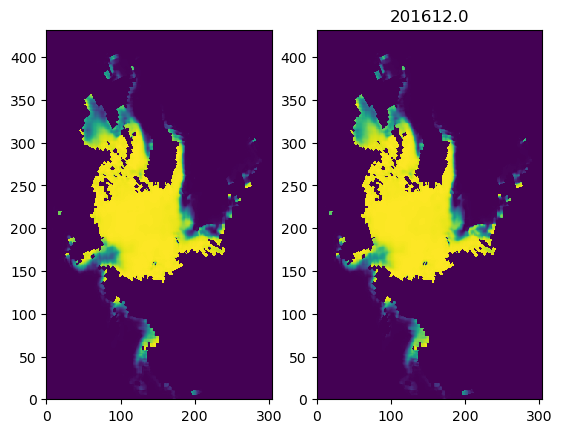

In [100]:
plt.subplot(1,2,1)
plt.pcolor(dict_target_mse[1]['latent_sampled'][0,0,0])
plt.subplot(1,2,2)
plt.pcolor(dict_target_mse[6]['latent_sampled'][0,0,0])
plt.title(f'{target_times[0]}')

In [79]:
ind201203 =  np.where(target_times == 201203)[0]
ind201309 =  np.where(target_times == 201309)[0]
q_1_201103_201309 = KLD( dict_target_mse[1]['mu'][ind201203,:], dict_target_mse[1]['log_var'][ind201203,:] , dict_target_mse[1]['mu'][ind201309,:] , dict_target_mse[1]['log_var'][ind201309,:])
p_1_201103_201309 = KLD( dict_target_mse[1]['cond_mu'][ind201203,:], dict_target_mse[1]['cond_log_var'][ind201203,:] , dict_target_mse[1]['cond_mu'][ind201309,:] , dict_target_mse[1]['cond_log_var'][ind201309,:])
q_1_6_201103 = KLD( dict_target_mse[1]['mu'][ind201203,:], dict_target_mse[1]['log_var'][ind201203,:] , dict_target_mse[6]['mu'][ind201203,:] , dict_target_mse[6]['log_var'][ind201203,:])
p_1_6_201103 = KLD( dict_target_mse[1]['cond_mu'][ind201203,:], dict_target_mse[1]['cond_log_var'][ind201203,:] , dict_target_mse[6]['cond_mu'][ind201203,:] , dict_target_mse[6]['cond_log_var'][ind201203,:])


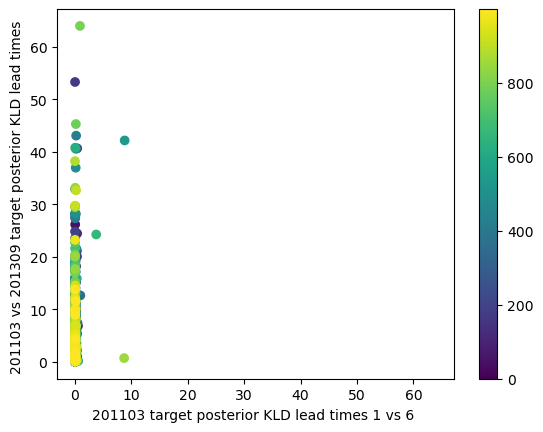

In [91]:

plt.scatter(q_1_6_201103, q_1_201103_201309 , c = np.arange(1000))
plt.xlabel('201103 target posterior KLD lead times 1 vs 6 ')
plt.ylabel('201103 vs 201309 target posterior KLD lead times ')
plt.xlim(plt.ylim()) 
plt.colorbar()




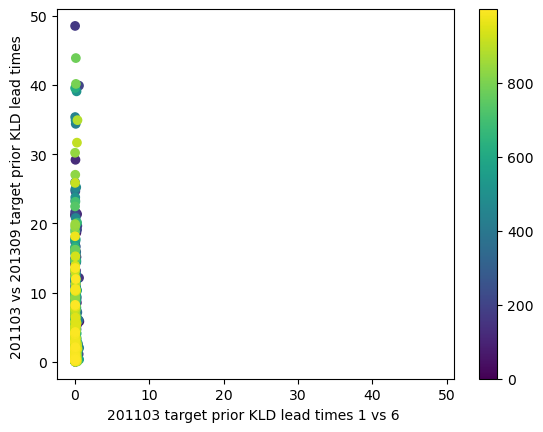

In [92]:
plt.scatter(p_1_6_201103, p_1_201103_201309 , c = np.arange(1000))
plt.xlabel('201103 target prior KLD lead times 1 vs 6 ')
plt.ylabel('201103 vs 201309 target prior KLD lead times ')
plt.xlim(plt.ylim()) 
plt.colorbar()

- based on intial months 

In [101]:
init_times_plot_lead_1

array([201003., 201004., 201005., 201006., 201007., 201008., 201009.,
       201010., 201011., 201012., 201101., 201102., 201103., 201104.,
       201105., 201106., 201107., 201108., 201109., 201110., 201111.,
       201112., 201201., 201202., 201203., 201204., 201205., 201206.,
       201207., 201208., 201209., 201210., 201211., 201212., 201301.,
       201302., 201303., 201304., 201305., 201306., 201307., 201308.,
       201309., 201310., 201311., 201312., 201401., 201402., 201403.,
       201404., 201405., 201406., 201407., 201408., 201409., 201410.,
       201411., 201412., 201501., 201502., 201503., 201504., 201505.,
       201506., 201507., 201508., 201509., 201510., 201511., 201512.])

In [104]:
init_times_plot_lead_6

array([201003., 201004., 201005., 201006., 201007., 201008., 201009.,
       201010., 201011., 201012., 201101., 201102., 201103., 201104.,
       201105., 201106., 201107., 201108., 201109., 201110., 201111.,
       201112., 201201., 201202., 201203., 201204., 201205., 201206.,
       201207., 201208., 201209., 201210., 201211., 201212., 201301.,
       201302., 201303., 201304., 201305., 201306., 201307., 201308.,
       201309., 201310., 201311., 201312., 201401., 201402., 201403.,
       201404., 201405., 201406., 201407., 201408., 201409., 201410.,
       201411., 201412., 201501., 201502., 201503., 201504., 201505.,
       201506., 201507.])

In [17]:

inds = np.where(lead_times == 1)
init_times_plot_lead_1 = times[inds][n_time_start:]

inds = np.where(lead_times == 6)
init_times_plot_lead_6 = times[inds][n_time_start:]

q_q_KLD = torch.full((len(init_times_plot_lead_1), len(init_times_plot_lead_6)), np.nan)
p_p_KLD = torch.full((len(init_times_plot_lead_1), len(init_times_plot_lead_6)), np.nan)
q_p_KLD = torch.full((len(init_times_plot_lead_1), len(init_times_plot_lead_6)), np.nan)

for ind_init_time in range(len(init_times_plot_lead_1)):
    mu1 = torch.broadcast_to(dict_data_mse[1]['mu'][ind_init_time][None,], dict_data_mse[6]['mu'].shape )
    log_var1 = torch.broadcast_to(dict_data_mse[1]['log_var'][ind_init_time][None,],dict_data_mse[6]['log_var'].shape )
    q_q_KLD[ind_init_time, :] = KLD(mu1, log_var1, dict_data_mse[6]['mu'], dict_data_mse[6]['log_var']).mean(axis = -1)

    mu1 = torch.broadcast_to(dict_data_mse[1]['cond_mu'][ind_init_time][None,], dict_data_mse[6]['cond_mu'].shape )
    log_var1 = torch.broadcast_to(dict_data_mse[1]['cond_log_var'][ind_init_time][None,],dict_data_mse[6]['cond_log_var'].shape )
    p_p_KLD[ind_init_time, :] = KLD(mu1, log_var1, dict_data_mse[6]['cond_mu'], dict_data_mse[6]['cond_log_var']).mean(axis = -1)

    mu1 = torch.broadcast_to(dict_data_mse[1]['mu'][ind_init_time][None,], dict_data_mse[6]['mu'].shape )
    log_var1 = torch.broadcast_to(dict_data_mse[1]['log_var'][ind_init_time][None,],dict_data_mse[6]['log_var'].shape )
    q_p_KLD[ind_init_time, :] = KLD(mu1, log_var1, dict_data_mse[6]['cond_mu'], dict_data_mse[6]['cond_log_var']).mean(axis = -1)

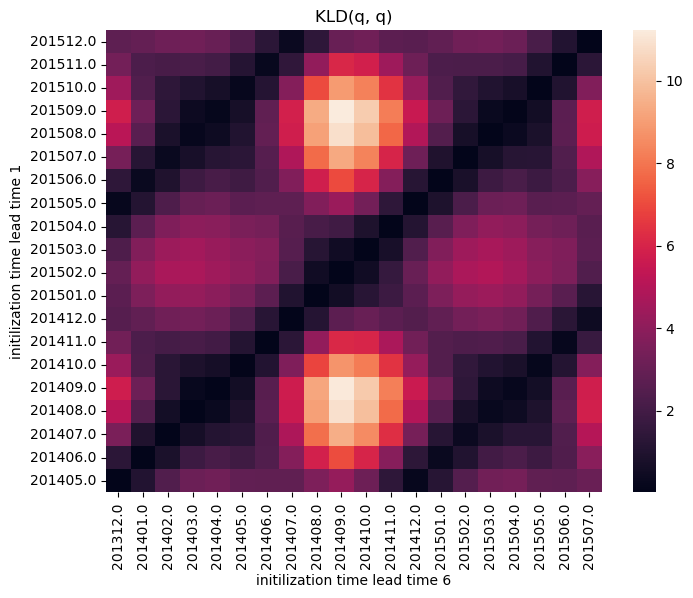

In [164]:
import seaborn as sns


# Example data

plt.figure(figsize=(8, 6))
sns.heatmap(q_q_KLD[-20:,-20:])
plt.yticks(np.arange(q_q_KLD[-20:,-20:].shape[0])+ 0.5, init_times_plot_lead_1[-20:], rotation = 0)
plt.xticks(np.arange(q_q_KLD[-20:,-20:].shape[1])+ 0.5, init_times_plot_lead_6[-20:] , rotation = 90)
plt.gca().invert_yaxis()
plt.ylabel('initilization time lead time 1')
plt.xlabel('initilization time lead time 6')
plt.title('KLD(q, q)')
plt.show()

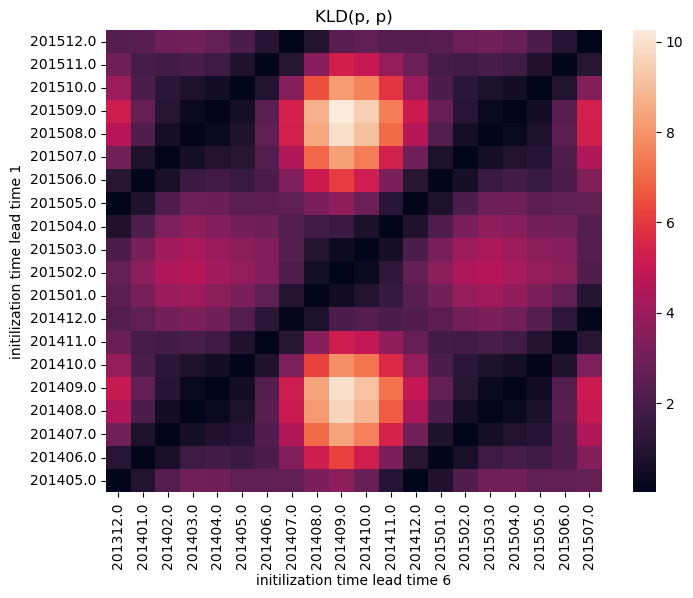

In [165]:
import seaborn as sns


# Example data

plt.figure(figsize=(8, 6))
sns.heatmap(p_p_KLD[-20:,-20:])
plt.yticks(np.arange(p_p_KLD[-20:,-20:].shape[0])+ 0.5, init_times_plot_lead_1[-20:], rotation = 0)
plt.xticks(np.arange(p_p_KLD[-20:,-20:].shape[1])+ 0.5, init_times_plot_lead_6[-20:] , rotation = 90)
plt.gca().invert_yaxis()
plt.ylabel('initilization time lead time 1')
plt.xlabel('initilization time lead time 6')
plt.title('KLD(p, p)')
plt.show()

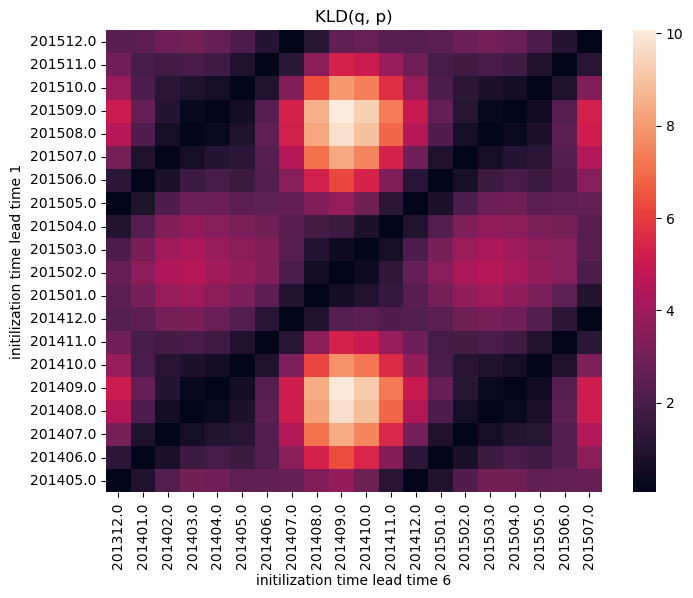

In [18]:
import seaborn as sns


# Example data

plt.figure(figsize=(8, 6))
sns.heatmap(q_p_KLD[-20:,-20:])
plt.yticks(np.arange(p_p_KLD[-20:,-20:].shape[0]) + 0.5, init_times_plot_lead_1[-20:], rotation = 0)
plt.xticks(np.arange(p_p_KLD[-20:,-20:].shape[1]) + 0.5, init_times_plot_lead_6[-20:] , rotation = 90)
plt.gca().invert_yaxis()
plt.ylabel('initilization time lead time 1')
plt.xlabel('initilization time lead time 6')
plt.title('KLD(q, p)')
plt.show()

- based on specified target

In [246]:
targtet_date = 201903

In [247]:


indtarget=  np.where(target_times == targtet_date)[0]
# ind201909 =  np.where(target_times == 201909)[0]

init_times_inds  =np.where(init_times_plot <= targtet_date)[0]
init_times_before  =init_times_plot[init_times_plot <= targtet_date]

mask = create_mask(np.zeros(( len(init_times_inds),len(dict_target_mse.keys()))))

pp_dict = np.full(( len(init_times_inds), len(dict_target_mse.keys()) ), np.nan)
qq_dict = np.full(( len(init_times_inds), len(dict_target_mse.keys())), np.nan)
qp_dict = np.full(( len(init_times_inds), len(dict_target_mse.keys())), np.nan)

for lead_time in dict_target_mse.keys():
    
    pp_dict[:,lead_time - 1] = np.array([KLD( dict_target_mse[1]['cond_mu'][indtarget,:], dict_target_mse[1]['cond_log_var'][indtarget,:] , dict_data_mse[lead_time]['cond_mu'][i,:] , dict_data_mse[lead_time]['cond_log_var'][i,:]).mean(axis = -1).numpy() for i in init_times_inds]).squeeze()
    qq_dict[:,lead_time- 1] = np.array([KLD( dict_target_mse[1]['mu'][indtarget,:], dict_target_mse[1]['log_var'][indtarget,:] , dict_data_mse[lead_time]['mu'][i,:] , dict_data_mse[lead_time]['log_var'][i,:]).mean(axis = -1).numpy() for i in init_times_inds]).squeeze()
    qp_dict[:, lead_time- 1] = np.array([KLD( dict_target_mse[1]['mu'][indtarget,:], dict_target_mse[1]['log_var'][indtarget,:] , dict_data_mse[lead_time]['cond_mu'][i,:] , dict_data_mse[lead_time]['cond_log_var'][i,:]).mean(axis = -1).numpy() for i in init_times_inds]).squeeze()

pp_dict =  np.where(~mask, pp_dict, np.nan)
qq_dict = np.where(~mask, qq_dict, np.nan)
qp_dict = np.where(~mask, qp_dict, np.nan)




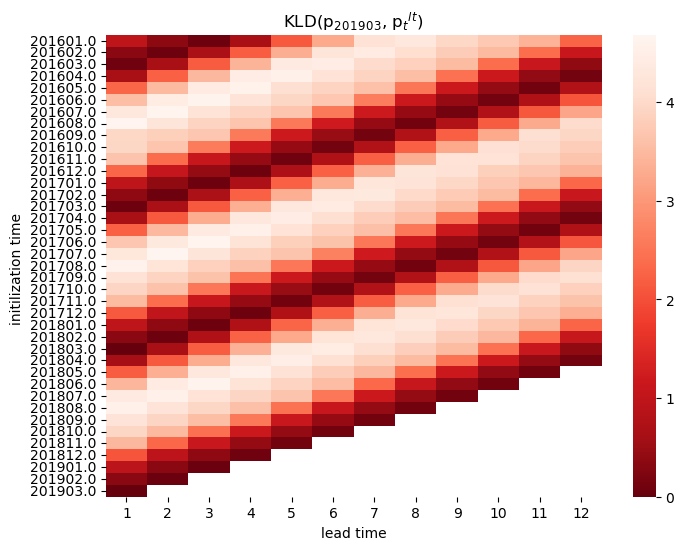

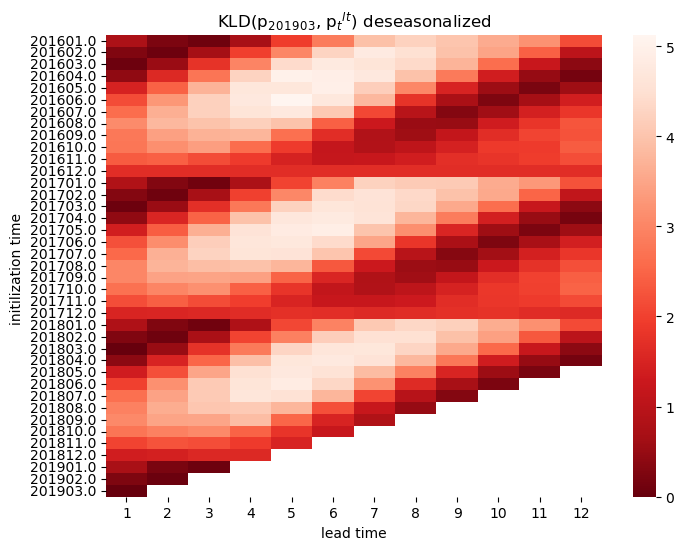

In [ ]:
import seaborn as sns


# Example data

plt.figure(figsize=(8, 6))
sns.heatmap(pp_dict, cmap = 'Reds_r')
plt.xticks(np.arange(12)+ 0.5, np.arange(1,13), rotation = 0)
plt.yticks(np.arange(pp_dict.shape[0])+ 0.5, init_times_before , rotation = 0)
# plt.gca().invert_yaxis()
plt.ylabel('initilization time ')
plt.xlabel('lead time')

target_subscript = ''
for letter in f'{targtet_date}':
    target_subscript = target_subscript + f'$_{letter}$'

plt.title(f'KLD(p{target_subscript}, p$_t$$^l$$^t$)')
plt.show()






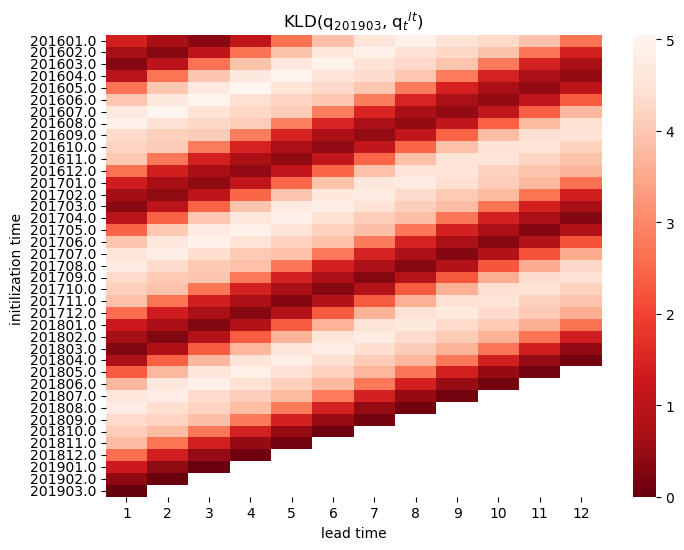

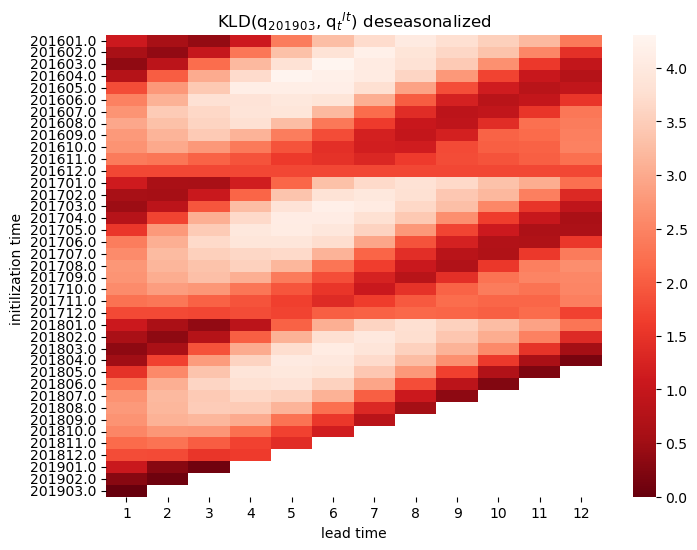

In [ ]:
import seaborn as sns


# Example data

plt.figure(figsize=(8, 6))
sns.heatmap(qq_dict, cmap = 'Reds_r')
plt.xticks(np.arange(12)+ 0.5, np.arange(1,13), rotation = 0)
plt.yticks(np.arange(qq_dict.shape[0])+ 0.5, init_times_before , rotation = 0)
# plt.gca().invert_yaxis()
plt.ylabel('initilization time ')
plt.xlabel('lead time')

target_subscript = ''
for letter in f'{targtet_date}':
    target_subscript = target_subscript + f'$_{letter}$'

plt.title(f'KLD(q{target_subscript}, q$_t$$^l$$^t$)')
plt.show()




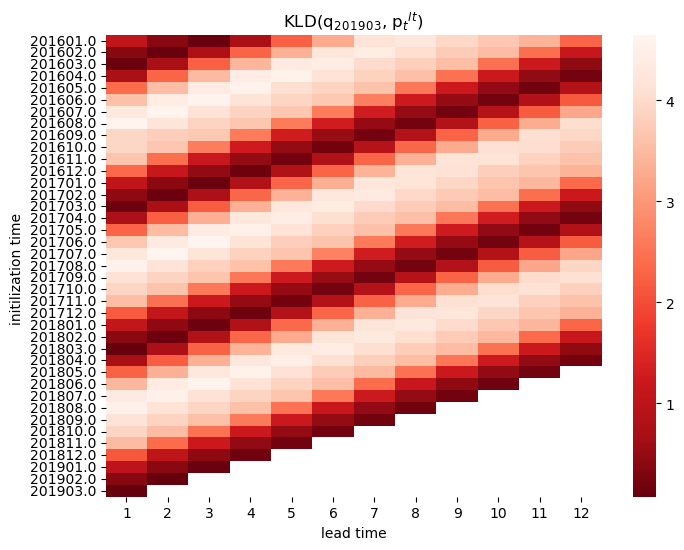

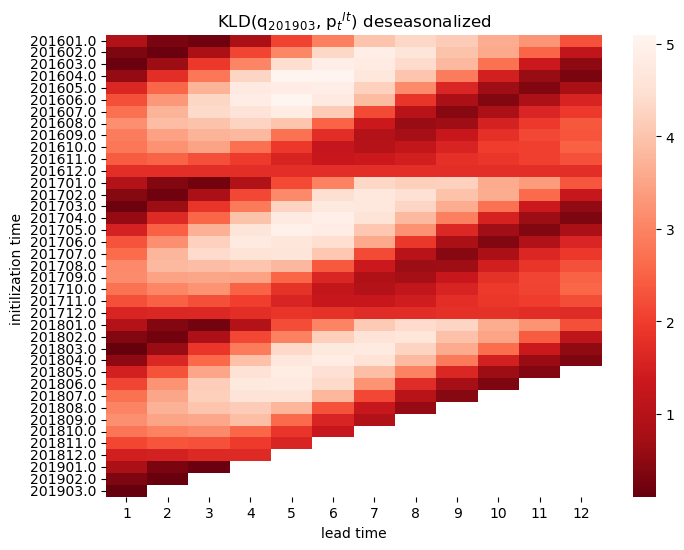

In [ ]:
import seaborn as sns


# Example data

plt.figure(figsize=(8, 6))
sns.heatmap(qp_dict, cmap = 'Reds_r')
plt.xticks(np.arange(12)+ 0.5, np.arange(1,13), rotation = 0)
plt.yticks(np.arange(qp_dict.shape[0])+ 0.5, init_times_before , rotation = 0)
# plt.gca().invert_yaxis()
plt.ylabel('initilization time ')
plt.xlabel('lead time')

target_subscript = ''
for letter in f'{targtet_date}':
    target_subscript = target_subscript + f'$_{letter}$'

plt.title(f'KLD(q{target_subscript}, p$_t$$^l$$^t$)')
plt.show()


import seaborn as sns


# Example data



- interannual test

In [165]:
import pickle

with open(f"{out_dir}/saved_model_{model_year}_latent_encodings.pkl", "rb") as f:
    dict_data_mse = pickle.load(f)

In [166]:
dict_data_mse_full = {}
for lead_time in dict_data_mse['Train'].keys():
    dict_data_mse_full[lead_time] = {}
    for key, ds in dict_data_mse['Train'][lead_time].items():
        if key == 'latent_sampled':
            pass
        else:
            if key == 'z_samples':
                axis = 1
            else:
                axis = 0
            try:
                dict_data_mse_full[lead_time][key] = torch.cat([ds, dict_data_mse['Test'][lead_time][key]], axis = axis)
            except:
                dict_data_mse_full[lead_time][key] = np.concatenate([ds, dict_data_mse['Test'][lead_time][key]], axis = axis)

In [ ]:
targtet_date = 201601

In [174]:


indtarget=  np.where(dict_data_mse_full[1]['target_times'] == targtet_date)[0]
# ind201909 =  np.where(target_times == 201909)[0]
init_times_plot = dict_data_mse_full[1]['init_times']

init_times_inds  =np.where(init_times_plot <= targtet_date)[0]
init_times_before  =init_times_plot[init_times_plot <= targtet_date]

mask = create_mask(np.zeros(( len(init_times_inds),len(dict_data_mse_full.keys()))))

pp_dict = np.full(( len(init_times_inds), len(dict_data_mse_full.keys()) ), np.nan)
qq_dict = np.full(( len(init_times_inds), len(dict_data_mse_full.keys())), np.nan)
pq_dict = np.full(( len(init_times_inds), len(dict_data_mse_full.keys())), np.nan)

for lead_time in dict_data_mse_full_deseason.keys():
    
    pp_dict[:,lead_time - 1] = np.array([KLD( dict_data_mse_full[1]['cond_mu'][indtarget,:], dict_data_mse_full[1]['cond_log_var'][indtarget,:] , dict_data_mse_full[lead_time]['cond_mu'][i,:] , dict_data_mse_full[lead_time]['cond_log_var'][i,:]).mean(axis = -1).numpy() for i in init_times_inds]).squeeze()
    qq_dict[:,lead_time- 1] = np.array([KLD( dict_data_mse_full[1]['mu'][indtarget,:], dict_data_mse_full[1]['log_var'][indtarget,:] , dict_data_mse_full[lead_time]['mu'][i,:] , dict_data_mse_full[lead_time]['log_var'][i,:]).mean(axis = -1).numpy() for i in init_times_inds]).squeeze()
    pq_dict[:, lead_time- 1] = np.array([KLD( dict_data_mse_full[1]['cond_mu'][indtarget,:], dict_data_mse_full[1]['cond_log_var'][indtarget,:] , dict_data_mse_full[lead_time]['mu'][i,:] , dict_data_mse_full[lead_time]['log_var'][i,:]).mean(axis = -1).numpy() for i in init_times_inds]).squeeze()

pp_dict =  np.where(~mask, pp_dict, np.nan)
qq_dict = np.where(~mask, qq_dict, np.nan)
pq_dict = np.where(~mask, pq_dict, np.nan)




In [175]:
def deseason_axis_zero(ds):

        clim = np.concatenate([ np.nanmean(ds[i::12,...],0)[None,] for i in np.arange(12)], axis = 0)
        clim =np.concatenate([clim for _ in range(int(np.ceil(ds.shape[0]/12)) )], axis = 0)
        return ds - clim[:ds.shape[0]]

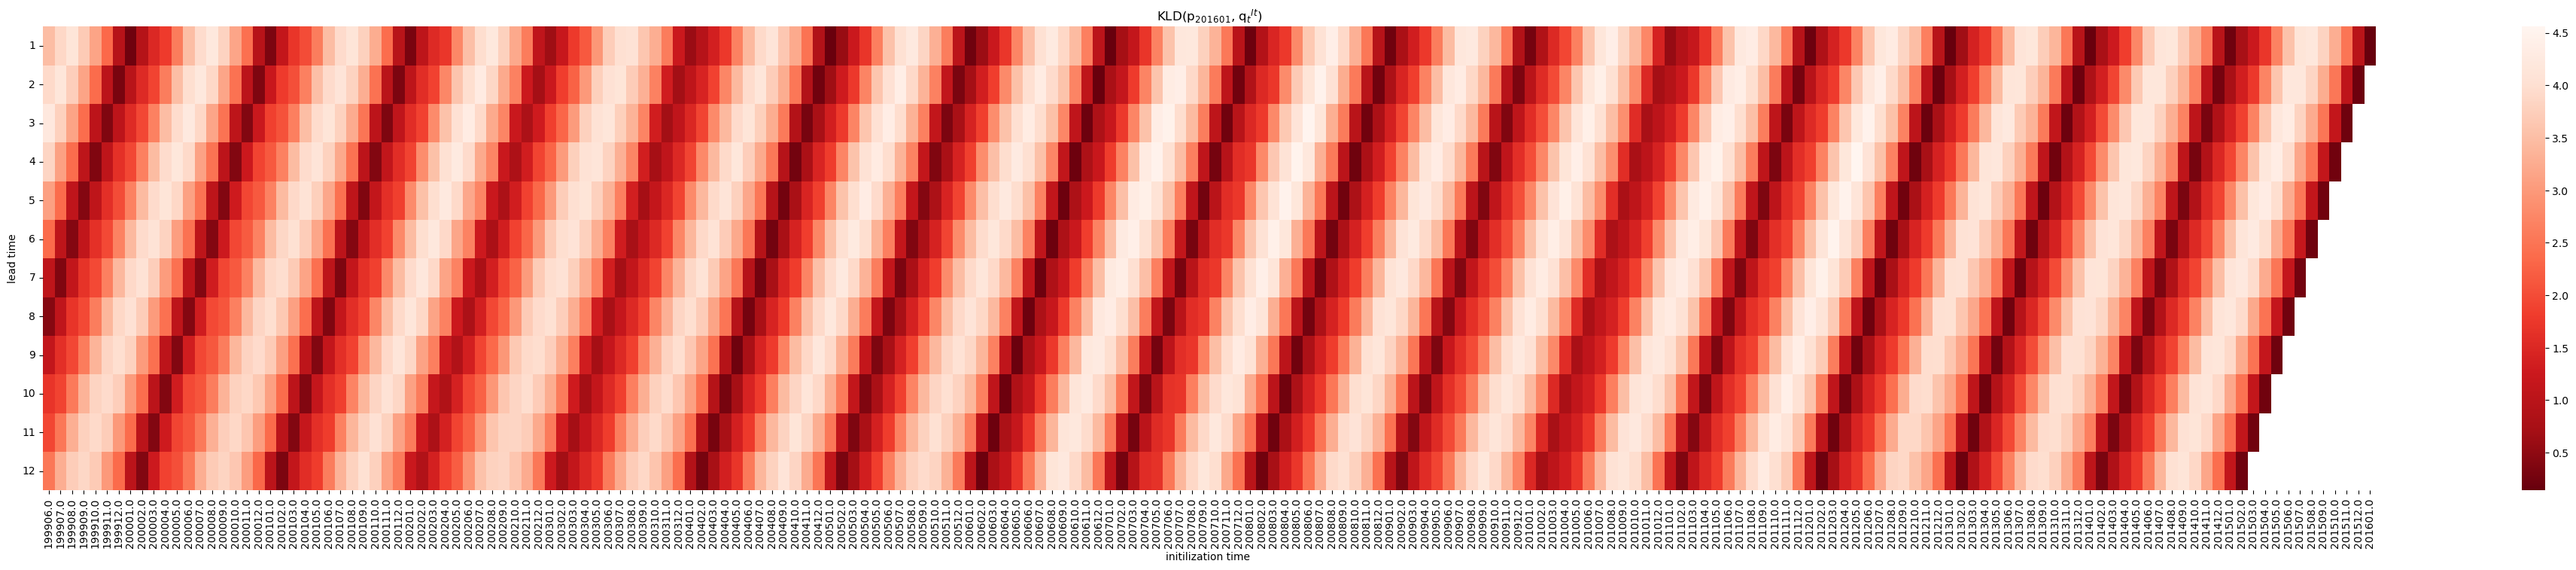

In [177]:
import seaborn as sns


# Example data

plt.figure(figsize=(50, 8))
sns.heatmap(pq_dict[-200:].transpose(), cmap = 'Reds_r')
plt.yticks(np.arange(12)+ 0.5, np.arange(1,13), rotation = 0)
plt.xticks(np.arange(pq_dict[-200:].shape[0])+ 0.5, init_times_before[-200:] , rotation = 90)
# plt.gca().invert_yaxis()
plt.xlabel('initilization time ')
plt.ylabel('lead time')

target_subscript = ''
for letter in f'{targtet_date}':
    target_subscript = target_subscript + f'$_{letter}$'

plt.title(f'KLD(p{target_subscript}, q$_t$$^l$$^t$)')
plt.show()







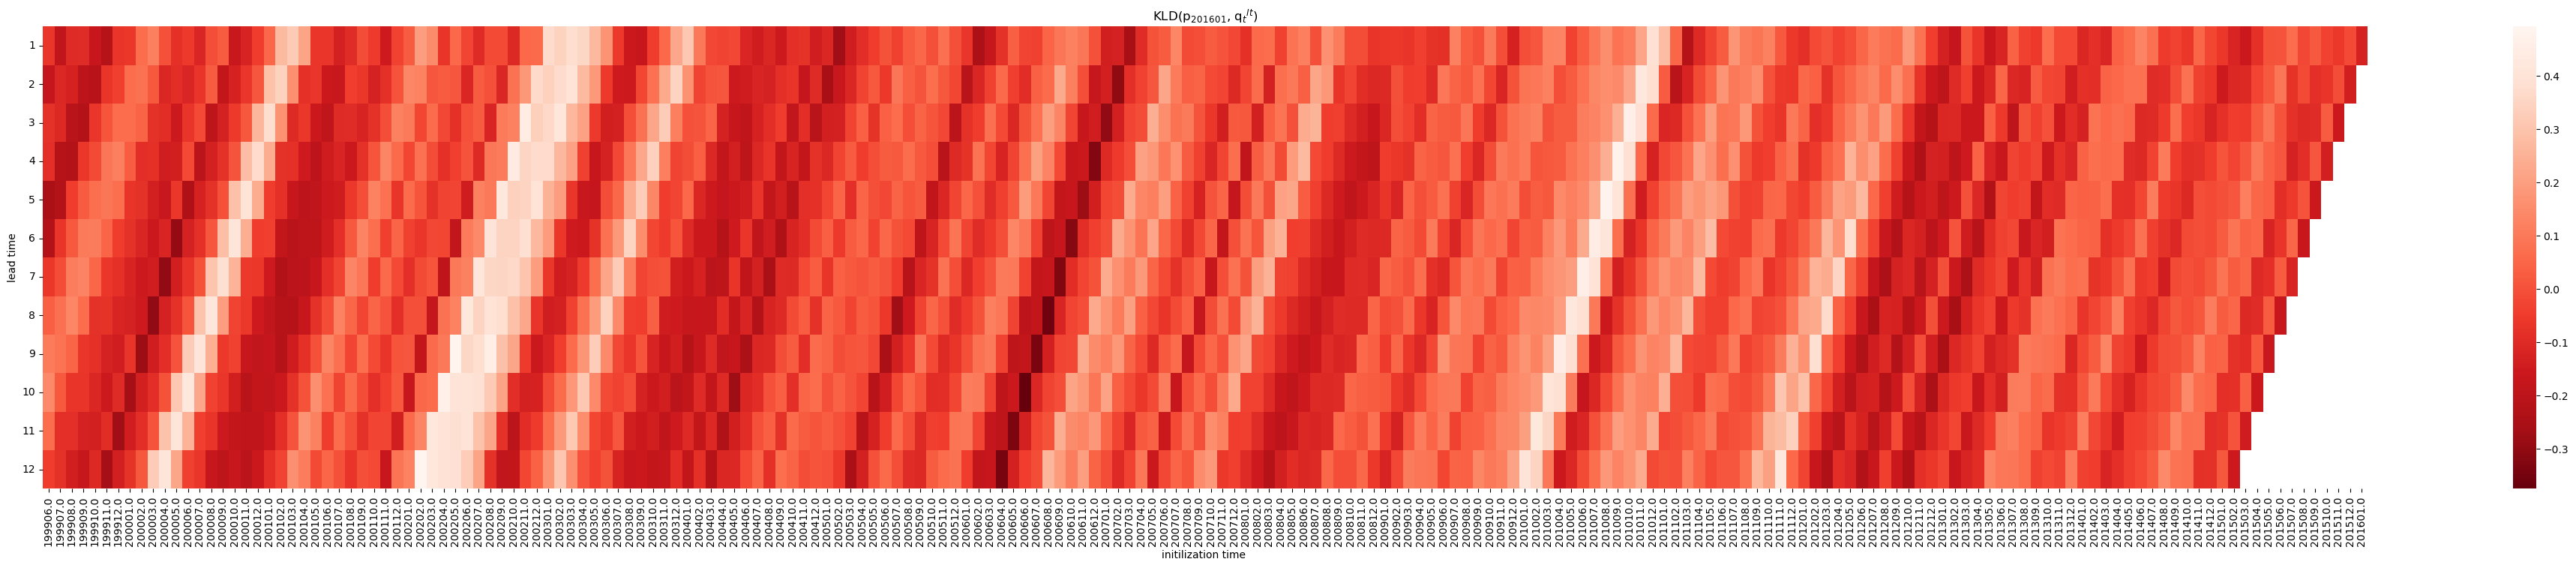

In [190]:
import seaborn as sns


# Example data

plt.figure(figsize=(50, 8))

sns.heatmap(  deseason_axis_zero(pq_dict[-200:]).transpose(), cmap = 'Reds_r')
plt.yticks(np.arange(12)+ 0.5, np.arange(1,13), rotation = 0)
plt.xticks(np.arange(pq_dict[-200:].shape[0])+ 0.5, init_times_before[-200:] , rotation = 90)
# plt.gca().invert_yaxis()
plt.xlabel('initilization time ')
plt.ylabel('lead time')

target_subscript = ''
for letter in f'{targtet_date}':
    target_subscript = target_subscript + f'$_{letter}$'

plt.title(f'KLD(p{target_subscript}, q$_t$$^l$$^t$)')
plt.show()




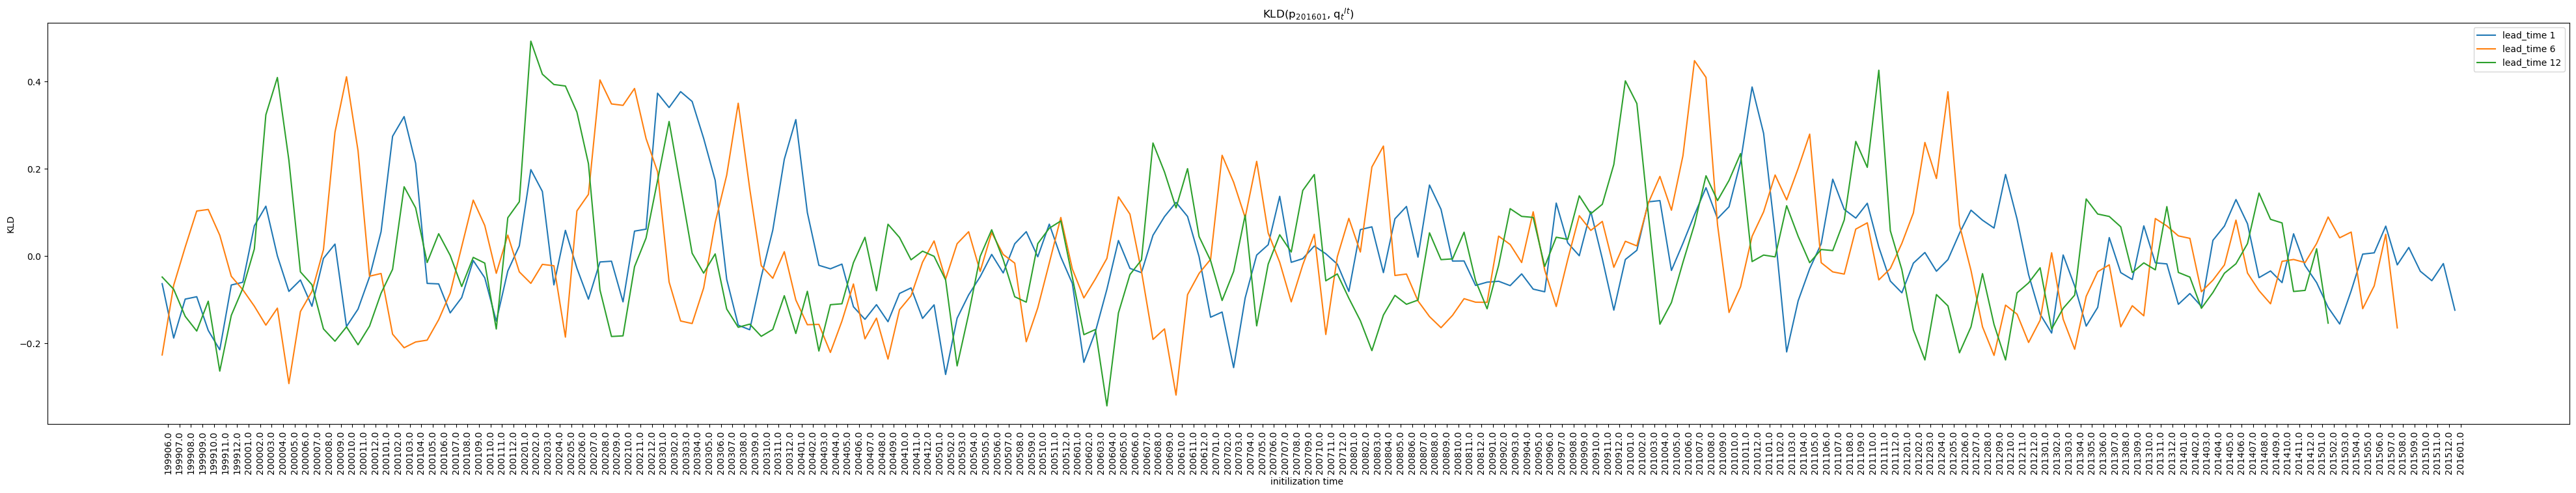

In [191]:
import seaborn as sns

lead_time_to_show = [1,6,12]
# Example data

plt.figure(figsize=(50, 8))
for i in lead_time_to_show:
    plt.plot(deseason_axis_zero(pq_dict[-200:, i-1]).transpose(), label = f'lead_time {i}')
plt.xticks(np.arange(pq_dict[-200:].shape[0])+ 0.5, init_times_before[-200:] , rotation = 90)
# plt.gca().invert_yaxis()
plt.xlabel('initilization time ')
plt.ylabel('KLD')

target_subscript = ''
for letter in f'{targtet_date}':
    target_subscript = target_subscript + f'$_{letter}$'

plt.title(f'KLD(p{target_subscript}, q$_t$$^l$$^t$)')
plt.legend()




In [192]:
        clim = np.concatenate([ np.nanmean(pq_dict[200+ i::12,...],0)[None,] for i in np.arange(12)], axis = 0)
        clim =np.concatenate([clim for _ in range(int(np.ceil(pq_dict[200:].shape[0]/12)) )], axis = 0)

/tmp/ipykernel_2232928/4044775459.py:36: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  plt.title(f'{np.int(times[inds][n_time_start:][time_ind])} - {latent_dist} sampling  \n {recons} lead_time {lead_time}')
/tmp/ipykernel_2232928/4044775459.py:80: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your cu

Text(0, 0.5, 'Log$_2$ Azimuthally-averaged power')

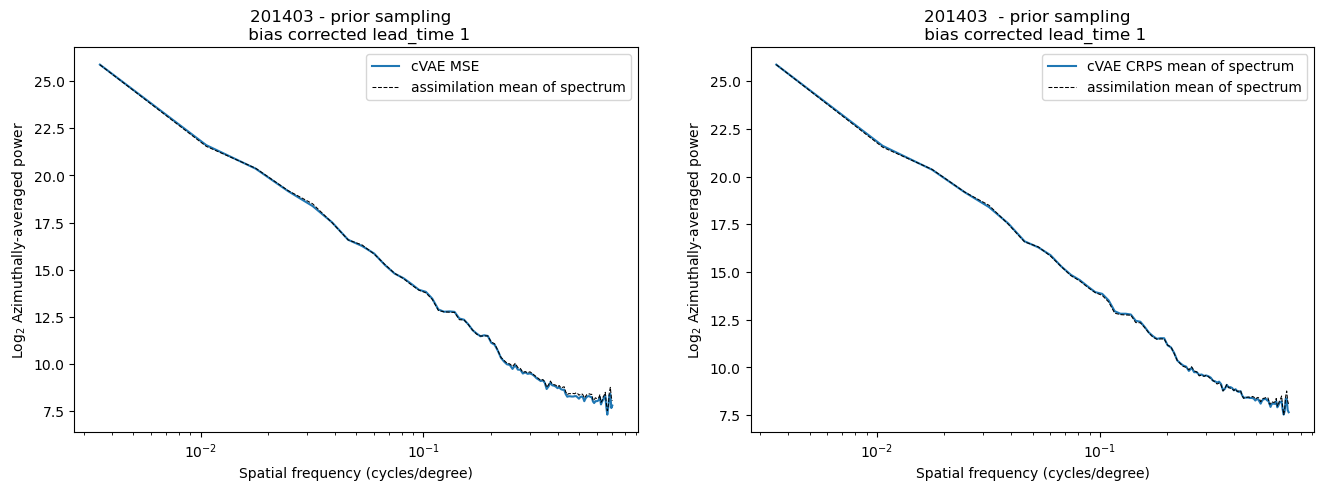

: 

In [ ]:
# numbins = 100
# plt.figure(figsize=(16,5))
# plt.subplot(1,2,1)
# if NPSProj:
#         data_pwr , data_wav= power((dstp_mse), numbins)
# else:
#         data_pwr , data_wav= power(reverse_pole_centric_array(dstp_mse), numbins)
# data_pwr = np.log2(data_pwr)
# plt.plot(data_wav,
#         data_pwr,
#         label=f'cVAE MSE')

# data_pwr_list = []
# for i in range(dstp_asm.shape[0]):
#         # if NPSProj:
#         data_pwr , data_wav = power((dstp_asm[i]),numbins)
#         # else:
#         #         data_pwr , data_wav = power(reverse_pole_centric_array(dstp_asm[i]),numbins)
#         data_pwr_list.append(np.log2(data_pwr))     
        
# data_pwr =  np.mean(data_pwr_list,axis=0)  
# # data_pwr , data_wav = power(reverse_pole_centric_array(dstp_asm),numbins)
# # data_pwr = np.log2(data_pwr)     
# plt.plot(data_wav,
#         data_pwr,
#         color = 'k',
#         linewidth = 0.75 ,
#         linestyle = 'dashed',
#         label=f'assimilation mean of spectrum')



# # plt.gca().invert_xaxis()       
# plt.legend()
# plt.xscale("log") 
# plt.title(f'{np.int(times[inds][n_time_start:][time_ind])} - {latent_dist} sampling  \n {recons} lead_time {lead_time}')
# plt.xlabel('Spatial frequency (cycles/degree)')
# plt.ylabel('Log$_2$ Azimuthally-averaged power')


# plt.subplot(1,2,2)
# data_pwr_list = []
# for i in range(dstp_crps.shape[0]):
#         if NPSProj:
#                 data_pwr , data_wav = power((dstp_crps[i]),numbins)
#         else:
#                 data_pwr , data_wav = power(reverse_pole_centric_array(dstp_crps[i]),numbins)
#         data_pwr_list.append(np.log2(data_pwr))     
        
# data_pwr =  np.mean(data_pwr_list,axis=0)  
# # data_pwr , data_wav = power(reverse_pole_centric_array(dstp_crps[decoder_ensemble_ind]),numbins)
# # data_pwr = np.log2(data_pwr)
# plt.plot(data_wav,
#         data_pwr,
#         label=f'cVAE CRPS mean of spectrum')


# data_pwr_list = []
# for i in range(dstp_asm.shape[0]):
#         # if NPSProj:
#         data_pwr , data_wav = power((dstp_asm[i]),numbins)
#         # else:
#         #         data_pwr , data_wav = power(reverse_pole_centric_array(dstp_asm[i]),numbins)
#         data_pwr_list.append(np.log2(data_pwr))    
         
# data_pwr =  np.mean(data_pwr_list,axis=0)      
# # data_pwr , data_wav = power(reverse_pole_centric_array(dstp_asm),numbins)
# # data_pwr = np.log2(data_pwr)     
# plt.plot(data_wav,
#         data_pwr,
#         color = 'k',
#         linewidth = 0.75 ,
#         linestyle = 'dashed',
#         label=f'assimilation mean of spectrum')


# # plt.gca().invert_xaxis()       
# plt.legend()
# plt.xscale("log") 
# plt.title(f'{np.int(times[inds][n_time_start:][time_ind])}  - {latent_dist} sampling  \n {recons} lead_time {lead_time}')
# plt.xlabel('Spatial frequency (cycles/degree)')
# plt.ylabel('Log$_2$ Azimuthally-averaged power')
